### 构建ETF轮动池（时点表）

#### 目标
生成一张ETF轮动池的时点表，包含三列：**股票代码**、**开始时间**、**结束时间**。

#### 时间轴
从 2021-01-01 开始，每半年一个窗口，到 2026-04-30 截止：

| 窗口 | 计算区间 | 时点表生效区间 |
|---|---|---|
| 1 | 2021-01-01 ~ 2021-06-30 | 2021-07-01 ~ 2021-12-31 |
| 2 | 2021-07-01 ~ 2021-12-31 | 2022-01-01 ~ 2022-06-30 |
| 3 | 2022-01-01 ~ 2022-06-30 | 2022-07-01 ~ 2022-12-31 |
| ... | ... | ... |
| 末 | 2025-10-01 ~ 2026-04-30 | 2026-05-01 ~ (不足半年也保留) |

#### 每个窗口的计算逻辑

1. **上市时间筛选：** ETF 上市日期距离窗口起始日 >= 半年（排除新发 ETF 的噪音）
2. **成交额筛选：** 在该窗口时间范围内，日均成交额 > 2000万
3. **相关性计算：** 用窗口内的日收益率，计算 ETF 之间的相关系数矩阵
4. **层次聚类选股：**
   - 用层次聚类（Hierarchical Clustering）将 ETF 分成若干组，组内高度相关、组间低相关
   - 从每组中选1只（优先选成交额最大的），最终凑够50只
   - 保证选出的50只彼此分散度高，不同"主题"各选一个代表

#### 避免未来信息
窗口 N 的计算结果，生效时间为窗口 N+1。例如用 2021-01-01 ~ 2021-06-30 的数据算出的池子，最早在 2021-07-01 才能使用。

#### 输出格式

| 股票代码 | 开始时间 | 结束时间 |
|---|---|---|
| 510050.XSHG | 2021-07-01 | 2021-12-31 |
| 510300.XSHG | 2021-07-01 | 2021-12-31 |
| ... | ... | ... |
| 510500.XSHG | 2022-01-01 | 2022-06-30 |
| ... | ... | ... |

In [44]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
from scipy.cluster.hierarchy import linkage, fcluster
from scipy.spatial.distance import squareform

# ========== 参数设定 ==========
POOL_SIZE = 50              # 每期选出的ETF数量
MONEY_THRESHOLD = 2e7       # 日均成交额阈值: 2000万
HALF_YEAR_DAYS = 183        # 半年天数，用于上市时间筛选
VOL_THRESHOLD = 0.05        # 年化波动率阈值: 5%
CORR_DEDUP = 0.95           # 相关系数超过此阈值的视为重复，只保留成交额最大的一只
REPLACE_CORR_GAP = 0.05     # 换出成本：新候选与池内平均相关性必须比旧标的低0.05才替换

# ========== 生成半年窗口 ==========
windows = []
start = datetime(2021, 1, 1)
end = datetime(2026, 4, 30)

while start <= end:
    w_end = datetime(start.year, 7, 1) - timedelta(days=1) if start.month == 1 else datetime(start.year, 12, 31)
    if w_end > end:
        w_end = end
    windows.append((start, w_end))
    start = w_end + timedelta(days=1)

print("共 %d 个窗口:" % len(windows))
for i, (s, e) in enumerate(windows):
    print("  窗口%d: %s ~ %s" % (i+1, s.strftime('%Y-%m-%d'), e.strftime('%Y-%m-%d')))

# ========== 逐窗口计算 ==========
all_results = []
prev_selected = set()

for w_idx, (w_start, w_end) in enumerate(windows):
    w_start_str = w_start.strftime('%Y-%m-%d')
    w_end_str = w_end.strftime('%Y-%-m-%d')

    print("\n=== 窗口%d: %s ~ %s ===" % (w_idx + 1, w_start_str, w_end_str))

    # 1. 获取该窗口结束日仍在上市的ETF
    etf_df = get_all_securities(types=['etf'], date=w_end_str)

    # 2. 上市时间 >= 窗口起始日 - 半年
    cutoff_date = w_start - timedelta(days=HALF_YEAR_DAYS)
    etf_df = etf_df[etf_df['start_date'] <= cutoff_date.date()]
    print("[筛选] 上市>=半年: %d 只" % len(etf_df))

    # 3. 逐只获取日线数据
    etf_codes = list(etf_df.index)
    price_data = {}
    sample_rows = None

    for code in etf_codes:
        try:
            df = get_price(code, start_date=w_start_str, end_date=w_end_str,
                           frequency='daily', fields=['close', 'money'],
                           skip_paused=True)
            if df is not None and len(df) > 10:
                price_data[code] = df
                if sample_rows is None:
                    sample_rows = len(df)
        except Exception:
            pass

    print("[数据] 获取到日线行情: %d 只, 示例行数: %s" % (len(price_data), sample_rows))

    # 4. 筛选日均成交额 > 2000万
    avg_money = {code: df['money'].mean() for code, df in price_data.items()}
    candidates = [code for code, money in avg_money.items() if money > MONEY_THRESHOLD]
    print("[筛选] 日均成交额>2000万: %d 只" % len(candidates))

    # 5. 筛选年化波动率 > 5%
    vol_dict = {}
    for code in candidates:
        close = price_data[code]['close']
        ret = close.pct_change().dropna()
        if len(ret) > 10:
            vol_dict[code] = ret.std() * np.sqrt(250)
    candidates = [code for code in candidates if vol_dict.get(code, 0) > VOL_THRESHOLD]
    print("[筛选] 年化波动率>5%%: %d 只" % len(candidates))

    if len(candidates) <= POOL_SIZE:
        print("[结果] 候选不足 %d 只，全部保留" % POOL_SIZE)
        selected = candidates
    else:
        # 6. 构建日收益率矩阵
        ret_dict = {}
        for code in candidates:
            close = price_data[code]['close']
            ret = close.pct_change().dropna()
            ret_dict[code] = ret

        returns = pd.DataFrame(ret_dict)
        print("[数据] 收益率矩阵: %d 行 x %d 列" % (returns.shape[0], returns.shape[1]))

        valid_mask = returns.isnull().mean() < 0.2
        returns = returns.loc[:, valid_mask]
        returns = returns.fillna(method='ffill').fillna(method='bfill')
        candidates = list(returns.columns)
        print("[数据] 有效列: %d 只" % len(candidates))

        corr_matrix = returns.corr()

        # 7. 去重：相关系数 > CORR_DEDUP 的ETF只保留成交额最大的一只
        to_remove = set()
        for i in range(len(candidates)):
            if candidates[i] in to_remove:
                continue
            for j in range(i + 1, len(candidates)):
                if candidates[j] in to_remove:
                    continue
                if corr_matrix.iloc[i, j] > CORR_DEDUP:
                    if avg_money.get(candidates[i], 0) >= avg_money.get(candidates[j], 0):
                        to_remove.add(candidates[j])
                    else:
                        to_remove.add(candidates[i])
                        break

        candidates = [c for c in candidates if c not in to_remove]
        corr_matrix = corr_matrix.loc[candidates, candidates]
        print("[去重] 相关系数>%.2f去掉: %d 只, 剩余: %d 只" % (CORR_DEDUP, len(to_remove), len(candidates)))

        if len(candidates) <= POOL_SIZE:
            print("[结果] 去重后候选不足 %d 只，全部保留" % POOL_SIZE)
            selected = candidates
        else:
            # 8. 层次聚类
            dist_matrix = np.clip(1 - corr_matrix, 0, 2)
            np.fill_diagonal(dist_matrix.values, 0)
            condensed_dist = squareform(dist_matrix.values, checks=False)
            Z = linkage(condensed_dist, method='ward')

            labels = fcluster(Z, t=POOL_SIZE, criterion='maxclust')
            n_clusters = len(set(labels))
            print("[聚类] 产生 %d 组" % n_clusters)

            cluster_map = {}
            for code, label in zip(corr_matrix.columns, labels):
                cluster_map.setdefault(label, []).append(code)

            group_sizes = [len(v) for v in cluster_map.values()]
            print("[聚类] 各组大小: min=%d, max=%d, mean=%.1f" % (
                min(group_sizes), max(group_sizes), np.mean(group_sizes)))

            # 9. 比例分配名额
            N = len(candidates)
            quotas = {}
            for cluster_id, group in cluster_map.items():
                quotas[cluster_id] = max(1, int(round(POOL_SIZE * len(group) / float(N))))

            total_quota = sum(list(quotas.values()))
            quota_diff = total_quota - POOL_SIZE
            if quota_diff != 0:
                sorted_clusters = sorted(quotas.keys(),
                                         key=lambda x: max(avg_money.get(c, 0) for c in cluster_map[x]))
                if quota_diff > 0:
                    for cid in sorted_clusters:
                        if quota_diff <= 0:
                            break
                        if quotas[cid] > 1:
                            quotas[cid] -= 1
                            quota_diff -= 1
                else:
                    for cid in reversed(sorted_clusters):
                        if quota_diff >= 0:
                            break
                        quotas[cid] += 1
                        quota_diff += 1

            print("[分配] 名额总和=%d" % sum(list(quotas.values())))

            # 10. 两阶段选标的
            # 阶段A: 聚类+成交额选出50只候选
            raw_selected = []
            for cluster_id, group in cluster_map.items():
                quota = quotas[cluster_id]
                group_sorted = sorted(group, key=lambda x: avg_money.get(x, 0), reverse=True)
                raw_selected.extend(group_sorted[:quota])

            if len(raw_selected) > POOL_SIZE:
                raw_selected.sort(key=lambda x: avg_money.get(x, 0), reverse=True)
                raw_selected = raw_selected[:POOL_SIZE]
            elif len(raw_selected) < POOL_SIZE:
                unselected = [c for c in candidates if c not in set(raw_selected)]
                unselected.sort(key=lambda x: avg_money.get(x, 0), reverse=True)
                for c in unselected:
                    if len(raw_selected) >= POOL_SIZE:
                        break
                    raw_selected.append(c)

            # 阶段B: 基于相关性的换出成本保护（跨聚类组）
            if w_idx > 0:
                raw_set = set(raw_selected)
                prev_not_in_raw = prev_selected - raw_set
                new_in_raw = raw_set - prev_selected

                # 计算池内（raw_selected）各标的与其余标的的平均相关系数
                raw_sel_codes = list(raw_selected)
                corr_in_pool = corr_matrix.loc[raw_sel_codes, raw_sel_codes]

                def avg_corr_to_others(code, pool_codes, corr_df):
                    """计算code与pool中其他标的的平均相关系数"""
                    if code not in corr_df.index or len(pool_codes) <= 1:
                        return 0.5
                    others = [c for c in pool_codes if c != code]
                    return corr_df.loc[code, others].mean()

                forced_keep = set()
                for old_code in prev_not_in_raw:
                    if old_code not in set(candidates):
                        continue

                    # 旧标的与池内其他标的的平均相关性
                    old_avg_corr = avg_corr_to_others(old_code, raw_sel_codes, corr_matrix)

                    # 在新候选中找相关性最低的（最有分散价值）
                    replaceable = [c for c in raw_selected
                                   if c not in prev_selected and c not in forced_keep]
                    if not replaceable:
                        continue

                    # 新候选的分散价值排序：与池内平均相关性越低越有价值
                    replaceable.sort(key=lambda c: avg_corr_to_others(c, raw_sel_codes, corr_matrix))

                    # 找到相关性最低的新候选
                    best_new = replaceable[0]
                    new_avg_corr = avg_corr_to_others(best_new, raw_sel_codes, corr_matrix)

                    # 只有新候选相关性显著更低（差距 >= REPLACE_CORR_GAP）才替换
                    if old_avg_corr - new_avg_corr >= REPLACE_CORR_GAP:
                        raw_selected.remove(best_new)
                        raw_selected.append(old_code)
                        forced_keep.add(old_code)

                if len(raw_selected) > POOL_SIZE:
                    raw_selected.sort(
                        key=lambda x: (x in prev_selected, avg_money.get(x, 0)), reverse=True)
                    raw_selected = raw_selected[:POOL_SIZE]
                elif len(raw_selected) < POOL_SIZE:
                    extras = [c for c in candidates if c not in set(raw_selected)]
                    extras.sort(key=lambda x: avg_money.get(x, 0), reverse=True)
                    for c in extras:
                        if len(raw_selected) >= POOL_SIZE:
                            break
                        raw_selected.append(c)

            selected = raw_selected

            if w_idx > 0:
                kept = len(prev_selected & set(selected))
                actual_turnover = 1 - kept / len(prev_selected)
                print("[相关性换出] 保留%d只, 替换%d只, 换手率: %.1f%%" % (
                    kept, len(prev_selected) - kept, actual_turnover * 100))
            print("[结果] 选出: %d 只" % len(selected))

    prev_selected = set(selected)

    # 11. 写入时点表
    if w_idx + 1 < len(windows):
        eff_start = windows[w_idx + 1][0]
        eff_end = windows[w_idx + 1][1]
    else:
        eff_start = w_end + timedelta(days=1)
        eff_end = eff_start + timedelta(days=180)

    print("[时点表] 生效期: %s ~ %s, %d 只" % (
        eff_start.strftime('%Y-%m-%d'), eff_end.strftime('%Y-%m-%d'), len(selected)))

    for code in selected:
        all_results.append({
            'code': code,
            'start_date': eff_start.strftime('%Y-%m-%d'),
            'end_date': eff_end.strftime('%Y-%m-%d'),
            'display_name': etf_df.loc[code, 'display_name'] if code in etf_df.index else ''
        })

# ========== 输出最终时点表 ==========
result_df = pd.DataFrame(all_results)
print("\n========== 最终时点表 ==========")
print("总记录数: %d" % len(result_df))
print("时间范围: %s ~ %s" % (result_df['start_date'].min(), result_df['end_date'].max()))
print("\n每期数量:")
print(result_df.groupby('start_date').size())
result_df

共 11 个窗口:
  窗口1: 2021-01-01 ~ 2021-06-30
  窗口2: 2021-07-01 ~ 2021-12-31
  窗口3: 2022-01-01 ~ 2022-06-30
  窗口4: 2022-07-01 ~ 2022-12-31
  窗口5: 2023-01-01 ~ 2023-06-30
  窗口6: 2023-07-01 ~ 2023-12-31
  窗口7: 2024-01-01 ~ 2024-06-30
  窗口8: 2024-07-01 ~ 2024-12-31
  窗口9: 2025-01-01 ~ 2025-06-30
  窗口10: 2025-07-01 ~ 2025-12-31
  窗口11: 2026-01-01 ~ 2026-04-30

=== 窗口1: 2021-01-01 ~ 2021-6-30 ===
[筛选] 上市>=半年: 297 只
[数据] 获取到日线行情: 297 只, 示例行数: 118
[筛选] 日均成交额>2000万: 105 只
[筛选] 年化波动率>5%: 101 只
[数据] 收益率矩阵: 117 行 x 101 列
[数据] 有效列: 101 只
[去重] 相关系数>0.95去掉: 45 只, 剩余: 56 只
[聚类] 产生 50 组
[聚类] 各组大小: min=1, max=2, mean=1.1
[分配] 名额总和=50
[结果] 选出: 50 只
[时点表] 生效期: 2021-07-01 ~ 2021-12-31, 50 只

=== 窗口2: 2021-07-01 ~ 2021-12-31 ===
[筛选] 上市>=半年: 332 只
[数据] 获取到日线行情: 332 只, 示例行数: 125
[筛选] 日均成交额>2000万: 119 只
[筛选] 年化波动率>5%: 113 只
[数据] 收益率矩阵: 124 行 x 113 列
[数据] 有效列: 113 只
[去重] 相关系数>0.95去掉: 58 只, 剩余: 55 只
[聚类] 产生 50 组
[聚类] 各组大小: min=1, max=2, mean=1.1
[分配] 名额总和=50
[相关性换出] 保留41只, 替换9只, 换手率: 18.0%
[结果] 选出: 50 只
[时点表] 生效期: 

,code,display_name,end_date,start_date
0,515000.XSHG,科技ETF,2021-12-31,2021-07-01
1,159901.XSHE,深证100ETF易方达,2021-12-31,2021-07-01
2,159902.XSHE,中小100ETF华夏,2021-12-31,2021-07-01
3,159905.XSHE,红利ETF工银,2021-12-31,2021-07-01
4,159920.XSHE,恒生ETF华夏,2021-12-31,2021-07-01
5,159928.XSHE,消费ETF汇添富,2021-12-31,2021-07-01
6,159997.XSHE,电子ETF天弘,2021-12-31,2021-07-01
7,159949.XSHE,创业板50ETF华安,2021-12-31,2021-07-01
8,159966.XSHE,创业板价值ETF华夏,2021-12-31,2021-07-01
9,159980.XSHE,有色ETF大成,2021-12-31,2021-07-01


=== 窗口1选出的ETF相关性统计 ===
共 34 只, 561 对

相关系数分布:
  均值: 0.3499
  中位数: 0.3566
  标准差: 0.2337
  最小值: -0.3335
  最大值: 0.9220

相关系数区间分布:
  [-1.0, 0.0): 36 对 (6.4%)
  [0.0, 0.2): 117 对 (20.9%)
  [0.2, 0.4): 163 对 (29.1%)
  [0.4, 0.6): 162 对 (28.9%)
  [0.6, 0.8): 71 对 (12.7%)
  [0.8, 1.0): 12 对 (2.1%)



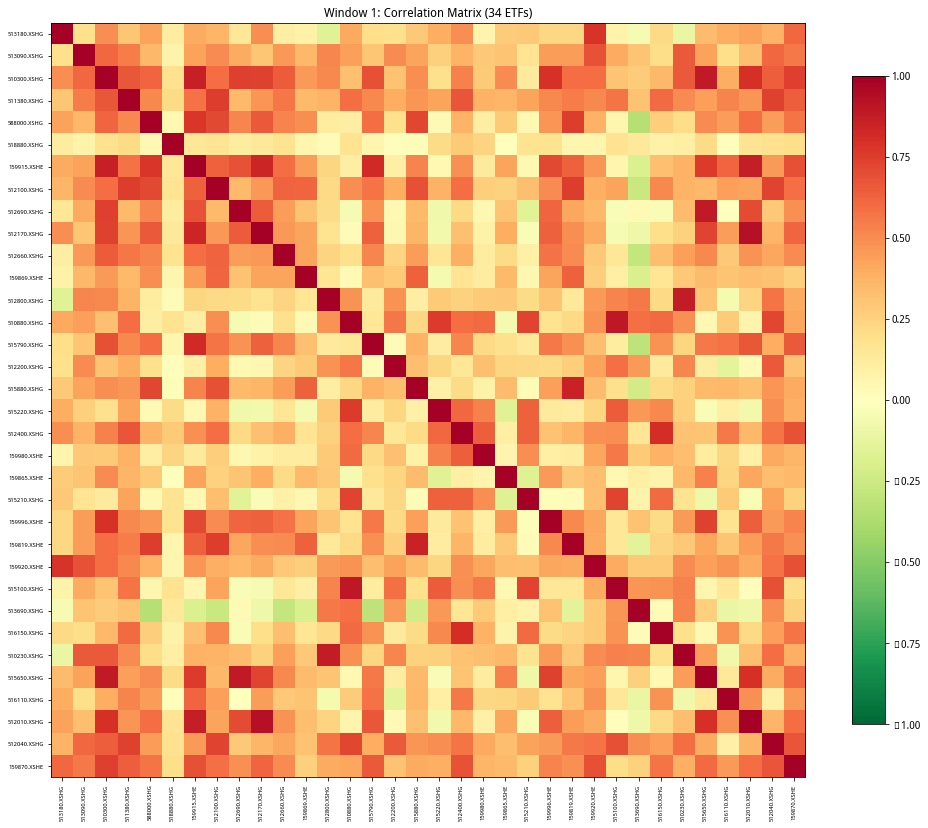


相关性最低的10对:
  588000.XSHG vs 513690.XSHG: -0.3335
  515790.XSHG vs 513690.XSHG: -0.2970
  512660.XSHG vs 513690.XSHG: -0.2749
  512100.XSHG vs 513690.XSHG: -0.2611
  515880.XSHG vs 513690.XSHG: -0.2224
  159869.XSHE vs 513690.XSHG: -0.1933
  159915.XSHE vs 513690.XSHG: -0.1860
  159865.XSHE vs 515210.XSHG: -0.1670
  515220.XSHG vs 159865.XSHE: -0.1613
  513180.XSHG vs 512800.XSHG: -0.1567

相关性最高的10对:
  159915.XSHE vs 515790.XSHG: 0.8250
  159915.XSHE vs 512170.XSHG: 0.8404
  515880.XSHG vs 159819.XSHE: 0.8552
  510300.XSHG vs 159915.XSHE: 0.8605
  159915.XSHE vs 512010.XSHG: 0.8680
  512800.XSHG vs 510230.XSHG: 0.8806
  510300.XSHG vs 515650.XSHG: 0.8846
  512690.XSHG vs 515650.XSHG: 0.8873
  510880.XSHG vs 515100.XSHG: 0.8963
  512170.XSHG vs 512010.XSHG: 0.9220


In [49]:
# ========== 验证窗口1选出的50只ETF之间的相关性 ==========
w1_pool = result_df[result_df['start_date'] == '2025-07-01']['code'].tolist()

w1_ret_dict = {}
for code in w1_pool:
    try:
        df = get_price(code, start_date='2021-01-01', end_date='2021-06-30',
                       frequency='daily', fields=['close'], skip_paused=True)
        if df is not None and len(df) > 10:
            w1_ret_dict[code] = df['close'].pct_change().dropna()
    except Exception:
        pass

w1_returns = pd.DataFrame(w1_ret_dict)
w1_corr = w1_returns.corr()
codes = list(w1_corr.columns)
n = len(codes)

print("=== 窗口1选出的ETF相关性统计 ===")
print("共 %d 只, %d 对" % (n, n * (n - 1) // 2))
print("")

mask = np.triu(np.ones(w1_corr.shape, dtype=bool), k=1)
corr_values = w1_corr.values[mask]

print("相关系数分布:")
print("  均值: %.4f" % corr_values.mean())
print("  中位数: %.4f" % np.median(corr_values))
print("  标准差: %.4f" % corr_values.std())
print("  最小值: %.4f" % corr_values.min())
print("  最大值: %.4f" % corr_values.max())
print("")

bins = [(-1, 0), (0, 0.2), (0.2, 0.4), (0.4, 0.6), (0.6, 0.8), (0.8, 1.01)]
print("相关系数区间分布:")
for lo, hi in bins:
    count = ((corr_values >= lo) & (corr_values < hi)).sum()
    pct = count * 100.0 / len(corr_values)
    print("  [%.1f, %.1f): %d 对 (%.1f%%)" % (lo, hi, count, pct))

print("")

import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(14, 12))
im = ax.imshow(w1_corr.values, cmap='RdYlGn_r', vmin=-1, vmax=1)
ax.set_xticks(range(n))
ax.set_yticks(range(n))
ax.set_xticklabels(codes, rotation=90, fontsize=6)
ax.set_yticklabels(codes, fontsize=6)
ax.set_title("Window 1: Correlation Matrix (%d ETFs)" % n, fontsize=12)
plt.colorbar(im, ax=ax, shrink=0.8)
plt.tight_layout()
plt.show()

corr_pairs = []
for i in range(n):
    for j in range(i+1, n):
        corr_pairs.append((codes[i], codes[j], w1_corr.iloc[i, j]))
corr_pairs.sort(key=lambda x: x[2])

print("\n相关性最低的10对:")
for a, b, c in corr_pairs[:10]:
    print("  %s vs %s: %.4f" % (a, b, c))

print("\n相关性最高的10对:")
for a, b, c in corr_pairs[-10:]:
    print("  %s vs %s: %.4f" % (a, b, c))

In [42]:
print(result_df.shape)
print(result_df.groupby('start_date').count())

(550, 4)
            code  display_name  end_date
start_date                              
2021-07-01    50            50        50
2022-01-01    50            50        50
2022-07-01    50            50        50
2023-01-01    50            50        50
2023-07-01    50            50        50
2024-01-01    50            50        50
2024-07-01    50            50        50
2025-01-01    50            50        50
2025-07-01    50            50        50
2026-01-01    50            50        50
2026-05-01    50            50        50


=== 相邻窗口标的变动率 ===

当前期             下期                   当前数      保留数      新增数      换手率  新增标的
----------------------------------------------------------------------------------------------------
2021-07-01      2022-01-01            50       41        9    18.0%  159807(科技ETF易方达), 159819(人工智能ETF易方达), 159825(农业ETF富国), 510050(50ETF), 510760(上证ETF) ...
2022-01-01      2022-07-01            50       37       13    26.0%  159745(建材ETF国泰), 159870(化工ETF鹏华), 159915(创业板ETF易方达), 511180(上证转债), 513060(恒生医疗) ...
2022-07-01      2023-01-01            50       44        6    12.0%  159766(旅游ETF富国), 159807(科技ETF易方达), 159881(有色金属ETF国泰), 512720(计算机), 516150(稀土基金) ...
2023-01-01      2023-07-01            50       44        6    12.0%  159845(中证1000ETF华夏), 159939(信息技术ETF广发), 510410(资源ETF), 513360(教育ETF), 513690(恒生股息) ...
2023-07-01      2024-01-01            50       44        6    12.0%  159662(交运ETF南方), 159851(金融科技ETF华宝), 510500(500ETF), 513180(恒指科技), 515100(红利100) ...
2024-01-01      2024-07-01        

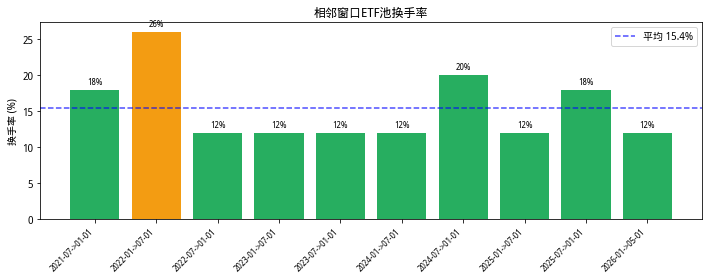

In [46]:
# ========== 相邻窗口标的变动率分析 ==========
periods = sorted(result_df['start_date'].unique())
pool_by_period = {p: set(result_df[result_df['start_date'] == p]['code']) for p in periods}

print("=== 相邻窗口标的变动率 ===\n")
print("%-15s %-15s %8s %8s %8s %8s  %s" % (
    "当前期", "下期", "当前数", "保留数", "新增数", "换手率", "新增标的"))
print("-" * 100)

turnover_rates = []
for i in range(len(periods) - 1):
    cur_pool = pool_by_period[periods[i]]
    nxt_pool = pool_by_period[periods[i + 1]]
    kept = cur_pool & nxt_pool
    added = nxt_pool - cur_pool
    removed = cur_pool - nxt_pool
    turnover = 1 - len(kept) / len(cur_pool) if len(cur_pool) > 0 else 0
    turnover_rates.append(turnover)

    added_names = []
    for code in sorted(added):
        name = result_df[result_df['code'] == code]['display_name'].values[0]
        added_names.append("%s(%s)" % (code[:6], name))

    print("%-15s %-15s %8d %8d %8d %7.1f%%  %s" % (
        periods[i], periods[i + 1],
        len(cur_pool), len(kept), len(added),
        turnover * 100,
        ", ".join(added_names[:5]) + (" ..." if len(added_names) > 5 else "")))

print("-" * 100)
print("平均换手率: %.1f%%" % (np.mean(turnover_rates) * 100))
print("最大换手率: %.1f%% (%s -> %s)" % (
    max(turnover_rates) * 100,
    periods[turnover_rates.index(max(turnover_rates))],
    periods[turnover_rates.index(max(turnover_rates)) + 1]))
print("最小换手率: %.1f%% (%s -> %s)" % (
    min(turnover_rates) * 100,
    periods[turnover_rates.index(min(turnover_rates))],
    periods[turnover_rates.index(min(turnover_rates)) + 1]))

# 累计稳定性：从第1期到最后一期一直保留的标的
always_present = set.intersection(*pool_by_period.values())
print("\n=== 全程保留的标的（所有窗口都在池中）===")
print("共 %d 只:" % len(always_present))
for code in sorted(always_present):
    name = result_df[result_df['code'] == code]['display_name'].values[0]
    print("  %s  %s" % (code, name))

# 可视化
fig, ax = plt.subplots(figsize=(10, 4))
x_labels = ["%s->%s" % (periods[i][:7], periods[i+1][5:10]) for i in range(len(periods) - 1)]
bars = ax.bar(range(len(turnover_rates)), [t * 100 for t in turnover_rates],
              color=['#e74c3c' if t > 0.4 else '#f39c12' if t > 0.2 else '#27ae60' for t in turnover_rates])
ax.set_xticks(range(len(x_labels)))
ax.set_xticklabels(x_labels, rotation=45, ha='right', fontsize=8)
ax.set_ylabel('换手率 (%)')
ax.set_title('相邻窗口ETF池换手率')
ax.axhline(y=np.mean(turnover_rates) * 100, color='blue', linestyle='--', alpha=0.7,
           label='平均 %.1f%%' % (np.mean(turnover_rates) * 100))
ax.legend()
for bar, rate in zip(bars, turnover_rates):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
            '%.0f%%' % (rate * 100), ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.show()

In [50]:
# ========== 导出时点表为CSV ==========
export_df = result_df.sort_values('start_date').reset_index(drop=True)
csv_path = 'etf_pool.csv'
export_df.to_csv(csv_path, index=False, encoding='utf-8-sig')
print("已导出 %d 条记录到 %s" % (len(export_df), csv_path))
export_df

已导出 550 条记录到 etf_pool.csv


,code,display_name,end_date,start_date
0,515000.XSHG,科技ETF,2021-12-31,2021-07-01
1,512580.XSHG,环保ETF,2021-12-31,2021-07-01
2,512660.XSHG,军工ETF,2021-12-31,2021-07-01
3,512690.XSHG,酒ETF,2021-12-31,2021-07-01
4,512720.XSHG,计算机,2021-12-31,2021-07-01
5,512800.XSHG,银行ETF,2021-12-31,2021-07-01
6,512880.XSHG,证券ETF,2021-12-31,2021-07-01
7,512960.XSHG,央调ETF,2021-12-31,2021-07-01
8,512980.XSHG,传媒ETF,2021-12-31,2021-07-01
9,513050.XSHG,中概互联,2021-12-31,2021-07-01
